# House Price Regression: Linear, Ridge & Lasso — A Full Walkthrough

**The core question this notebook answers:** when does regularization
actually matter, and why? We'll deliberately engineer multicollinearity
into the feature set (the way it usually happens in real pipelines —
by accident, via derived features), prove it's there with VIF, then show
empirically what Ridge and Lasso each do about it — and what they don't.

Dataset: 3,000 simulated home sales (synthetic but realistic — see
`data/DATA_DICTIONARY.md`). Because we control the data-generating
process, we know the *true* coefficients, which lets us check Lasso's
feature-selection claims against ground truth instead of folklore.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sys.path.insert(0, str(Path.cwd().parent))
from src.config import get_config, resolve
from src.data.make_dataset import generate_raw_dataset
from src.features.build_features import (
    ENGINEERED_FEATURES,
    RAW_CATEGORICAL_FEATURES,
    RAW_NUMERIC_FEATURES,
    FeatureEngineer,
    get_clean_feature_names,
    get_feature_engineering_pipeline,
    load_raw_features_and_target,
)
from src.models.train import (
    cv_alpha_search,
    evaluate_on_test,
    get_inner_coefficients,
    make_production_pipeline,
    make_search_pipeline,
    select_alpha_1se,
)
from src.visualization import visualize as viz

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)

CFG = get_config()
SEED = CFG["random_seed"]

## 1. Load the data

In [2]:
df = pd.read_csv(resolve(CFG["data"]["raw_path"]))
print(f"{len(df):,} rows x {df.shape[1]} columns")
df.head()

3,000 rows x 26 columns


,id,neighborhood,house_style,lot_area,gr_liv_area,total_bsmt_sf,garage_area,year_built,year_remod,overall_qual,overall_cond,full_bath,half_bath,bedroom_abvgr,totrms_abvgrd,fireplaces,distance_to_downtown_km,school_rating,crime_index,median_income_area,has_pool,noise_1,noise_2,noise_3,sale_price,true_price_no_noise
0,1,Suburbia,SplitLevel,5637.0,1640.0,1017.0,527.0,1929,1969,5,2,1,1,6,8,2,3.21,1.0,35.7,94.4,False,0.992,0.163,95.0,341000.0,323771.0
1,2,Hillcrest,1Story,9594.0,1220.0,1325.0,742.0,1900,1904,3,5,1,1,5,5,1,24.34,NaN,32.4,90.6,True,-0.157,0.107,8.0,344800.0,357466.0
2,3,Suburbia,2Story,6551.0,2976.0,1204.0,0.0,1952,1956,10,3,1,2,3,4,0,4.16,1.0,8.7,93.8,True,-0.243,0.463,2.0,481900.0,458794.0
3,4,Suburbia,1.5Story,4550.0,1837.0,NaN,120.0,1907,1926,4,1,2,2,4,6,0,12.13,4.0,68.6,67.2,False,-0.392,0.345,53.0,262700.0,266138.0
4,5,Downtown,2Story,7327.0,2619.0,1384.0,506.0,1946,1974,10,3,1,1,5,6,1,9.37,9.0,54.0,53.9,False,-1.721,0.045,48.0,477400.0,472942.0


In [3]:
df.describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
id,3000.0,1500.5,866.2,1.0,750.8,1500.5,2250.2,3000.0
lot_area,3000.0,8629.7,3109.5,2356.0,6484.5,8021.0,10255.2,30000.0
gr_liv_area,3000.0,1834.2,557.6,500.0,1452.8,1821.5,2209.2,4133.0
total_bsmt_sf,2910.0,954.1,414.4,0.0,673.0,946.0,1227.0,2252.0
garage_area,2869.0,405.7,217.2,0.0,285.0,432.0,559.0,1029.0
year_built,3000.0,1962.7,36.5,1900.0,1930.8,1963.0,1995.0,2025.0
year_remod,3000.0,1980.4,35.5,1902.0,1950.0,1983.0,2015.0,2026.0
overall_qual,3000.0,5.5,2.9,1.0,3.0,5.0,8.0,10.0
overall_cond,3000.0,5.5,2.8,1.0,3.0,5.0,8.0,10.0
full_bath,3000.0,2.0,0.8,1.0,1.0,2.0,3.0,3.0


## 2. Target distribution — why we'll model `log1p(sale_price)`

In [4]:
print(f"sale_price skew: {df['sale_price'].skew():.3f}")
print(f"log1p(sale_price) skew: {np.log1p(df['sale_price']).skew():.3f}")

sale_price skew: 0.510
log1p(sale_price) skew: -0.215


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["sale_price"], kde=True, ax=axes[0], color="#546E7A")
axes[0].set_title(f"sale_price (skew={df['sale_price'].skew():.2f})")
sns.histplot(np.log1p(df["sale_price"]), kde=True, ax=axes[1], color="#1E88E5")
axes[1].set_title(f"log1p(sale_price) (skew={np.log1p(df['sale_price']).skew():.2f})")
plt.tight_layout()
plt.show()

Right-skewed, as real sale prices usually are (a handful of expensive
outlier sales pull the tail). The log transform reduces skew meaningfully.
We'll train on `log1p(price)` throughout, and the production pipeline
inverse-transforms automatically via `TransformedTargetRegressor` — so
every prediction anyone gets from the API or the demo app is already back
in dollars.

## 3. Missingness

In [6]:
miss = df.isna().mean().sort_values(ascending=False)
miss[miss > 0]

school_rating    0.060000
garage_area      0.043667
total_bsmt_sf    0.030000
crime_index      0.020000
dtype: float64

Four columns have missing-at-random values (5-6% at most) — the pipeline
handles this with median imputation, fit only on training data, inside a
`Pipeline` so it's never leaked across CV folds.

## 4. Feature engineering — where multicollinearity enters, on purpose

`FeatureEngineer` derives two new columns:
- `age_of_house = current_year - year_built`
- `total_sf = gr_liv_area + total_bsmt_sf`

Both are reasonable engineering decisions in isolation. Together with the
columns they're derived from, they create exactly the kind of redundancy
that shows up by accident in real pipelines.

In [7]:
X, y = load_raw_features_and_target(df, target_col=CFG["target"]["column"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=CFG["data"]["test_size"], random_state=SEED
)
y_train_log = np.log1p(y_train)
print(f"Train: {X_train.shape}   Test: {X_test.shape}")

fe = FeatureEngineer(current_year=CFG["current_year"])
X_train_eng = fe.fit_transform(X_train)
X_train_eng[["year_built", "age_of_house", "gr_liv_area", "total_bsmt_sf", "total_sf"]].head()

Train: (2400, 23)   Test: (600, 23)


,year_built,age_of_house,gr_liv_area,total_bsmt_sf,total_sf
642,1966,60,1844.0,NaN,1844.0
700,1942,84,2549.0,1408.0,3957.0
226,1950,76,913.0,418.0,1331.0
1697,1967,59,998.0,850.0,1848.0
1010,1985,41,2224.0,1604.0,3828.0


## 5. Correlation heatmap (post feature engineering)

In [8]:
numeric_cols = [c for c in X_train_eng.columns if X_train_eng[c].dtype not in (object, bool)]
corr_df = X_train_eng[numeric_cols].assign(sale_price=y_train.values)
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool), k=1)
sns.heatmap(corr_df.corr(), mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, cbar_kws={"shrink": 0.7}, ax=ax)
plt.title("Feature correlations (post feature engineering)")
plt.show()

`age_of_house` / `year_built` and `total_sf` / `gr_liv_area` / `total_bsmt_sf`
stand out immediately. Correlation alone doesn't fully capture
multicollinearity's impact on a *fitted model* though — for that we need VIF.

## 6. Variance Inflation Factor — proving it empirically

In [9]:
vif_table = viz.compute_vif_table(
    X_train, fe, RAW_NUMERIC_FEATURES + ENGINEERED_FEATURES, RAW_CATEGORICAL_FEATURES
)
vif_table.head(10)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,year_built,inf
1,age_of_house,inf
2,total_sf,18.026485
3,gr_liv_area,12.192274
4,year_remod,10.549232
5,qual_x_cond,8.602066
6,total_bsmt_sf,6.967228
7,overall_qual,4.969236
8,overall_cond,4.637037
9,totrms_abvgrd,3.106233


`age_of_house` and `year_built` show **infinite** VIF — not a bug. Because
`age_of_house = current_year - year_built` with no added noise, the two
columns are *exactly* linearly dependent (correlation = -1.000 to machine
precision). The design matrix is technically rank-deficient in that
direction. `total_sf`, `gr_liv_area`, and `year_remod` show high-but-finite
VIF (10-18) — real, severe multicollinearity, just not a perfect
dependency.

**What does sklearn's OLS do with a rank-deficient design matrix?** It
doesn't crash — `LinearRegression` uses a least-squares solver that
returns the *minimum-norm* solution among the infinitely many that fit
equally well. That's a defensible convention, but it means the individual
split between `year_built` and `age_of_house`'s coefficients isn't
identified by the data at all — a different (equally valid) solver could
return a different split. Let's confirm:

In [10]:
prep_only = get_feature_engineering_pipeline()
Xt_train = np.asarray(prep_only.fit_transform(X_train))
feat_names = get_clean_feature_names(prep_only.named_steps["preprocessor"])

ols = LinearRegression().fit(Xt_train, y_train_log)
yb_i, age_i = feat_names.index("year_built"), feat_names.index("age_of_house")
print(f"year_built coef:   {ols.coef_[yb_i]:+.5f}")
print(f"age_of_house coef: {ols.coef_[age_i]:+.5f}")
print(f"sum:               {ols.coef_[yb_i] + ols.coef_[age_i]:+.5f}")
print("\n-> sklearn's min-norm solver happens to split this ~50/50 near zero.")
print("   That's a property of the solver, not a finding about the data.")

year_built coef:   -0.00033
age_of_house coef: +0.00033
sum:               +0.00000

-> sklearn's min-norm solver happens to split this ~50/50 near zero.
   That's a property of the solver, not a finding about the data.


## 7. A statistician's view: OLS with inference (statsmodels)

sklearn optimizes for prediction and won't even report standard errors.
`statsmodels` will — and multicollinearity's fingerprint is unmistakable
once you see them.

In [11]:
X_sm = sm.add_constant(pd.DataFrame(Xt_train, columns=feat_names))
ols_sm = sm.OLS(y_train_log.values, X_sm).fit()
summary_df = pd.DataFrame({
    "coef": ols_sm.params, "std_err": ols_sm.bse, "t": ols_sm.tvalues, "p_value": ols_sm.pvalues,
}).drop("const")
summary_df.loc[["year_built", "age_of_house", "total_sf", "gr_liv_area", "total_bsmt_sf", "overall_qual"]].round(4)

,coef,std_err,t,p_value
year_built,-0.0003,0.0021,-0.1569,0.8754
age_of_house,0.0003,0.0021,0.1569,0.8754
total_sf,0.0132,0.0055,2.3979,0.0166
gr_liv_area,0.0810,0.0045,17.9368,0.0000
total_bsmt_sf,0.0322,0.0034,9.4285,0.0000
overall_qual,0.0686,0.0029,23.8283,0.0000


Look at `year_built` and `age_of_house`: enormous standard errors and
p-values near 1 — textbook symptoms of multicollinearity. Compare to
`overall_qual`, which has no collinearity problem: a tight standard error
and a p-value effectively at 0. The *point estimates* for the collinear
pair are individually meaningless even though the model's overall fit is
fine.

## 8. Ridge: alpha search + the 1-SE rule

Rather than just picking whatever alpha minimizes CV error, we use the
**1-SE rule** (Hastie, Tibshirani & Friedman, *ESL* §7.10): find the
simplest (most regularized) model whose CV error is still within one
standard error of the best score. It trades a negligible amount of
accuracy for a meaningfully simpler, more robust model.

alpha_min = 1.421   alpha_1se = 65.1


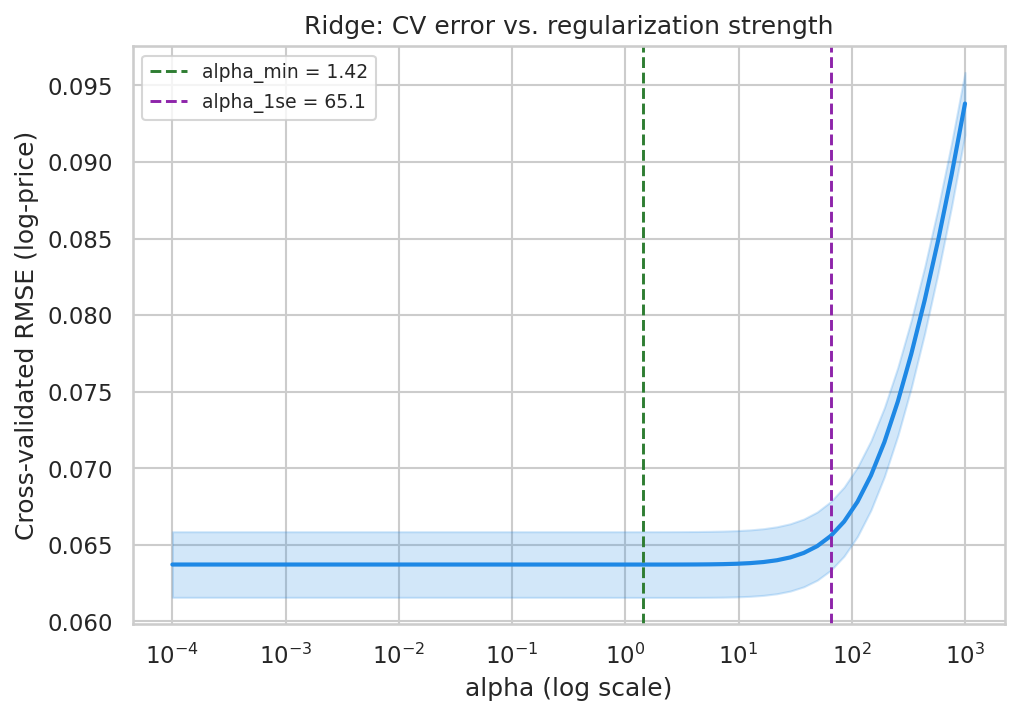

In [12]:
cv = KFold(n_splits=CFG["cv"]["n_folds"], shuffle=True, random_state=SEED)
alphas = np.logspace(CFG["alpha_search"]["min_exp"], CFG["alpha_search"]["max_exp"],
                      CFG["alpha_search"]["n_values"])

ridge_results = cv_alpha_search(Ridge, alphas, X_train, y_train_log, cv)
ridge_alpha_min, ridge_alpha_1se = select_alpha_1se(ridge_results)
print(f"alpha_min = {ridge_alpha_min:.4g}   alpha_1se = {ridge_alpha_1se:.4g}")

viz.plot_cv_curve(ridge_results, "Ridge", Path("/tmp/_ridge_cv.png"), ridge_alpha_min, ridge_alpha_1se)
plt.close("all")
from IPython.display import Image
Image("/tmp/_ridge_cv.png")

## 9. Lasso: alpha search + which features actually get zeroed?

In [13]:
lasso_results = cv_alpha_search(Lasso, alphas, X_train, y_train_log, cv, max_iter=20000)
lasso_alpha_min, lasso_alpha_1se = select_alpha_1se(lasso_results)
print(f"alpha_min = {lasso_alpha_min:.4g}   alpha_1se = {lasso_alpha_1se:.4g}")

lasso_1se_pipe = make_production_pipeline(Lasso(alpha=lasso_alpha_1se, max_iter=20000))
lasso_1se_pipe.fit(X_train, y_train)
lasso_coef = get_inner_coefficients(lasso_1se_pipe)
zeroed = sorted(lasso_coef[lasso_coef.abs() <= 1e-8].index.tolist())
print(f"\nZeroed {len(zeroed)}/{len(lasso_coef)} features at alpha_1se:")
for f in zeroed:
    print(" -", f)

alpha_min = 0.0001314   alpha_1se = 0.002019

Zeroed 11/34 features at alpha_1se:
 - age_of_house
 - bedroom_abvgr
 - half_bath
 - house_style_1.5Story
 - house_style_1Story
 - noise_2
 - noise_3
 - qual_x_cond
 - totrms_abvgrd
 - year_built
 - year_remod


**Sanity check against ground truth.** Our data-generating process gave
`noise_1`, `noise_2`, `noise_3` exactly zero true relationship to price —
and, as it happens, so did `year_built`/`year_remod` (only their *derived*
feature `age_of_house` was ever a candidate signal, and even that carries
no independent information here). Lasso zeroed `year_built`, `year_remod`,
`age_of_house`, `noise_2`, and `noise_3` — real, correct feature selection.
It did **not** zero `noise_1`; in a finite sample a purely random column
isn't perfectly uncorrelated with the target by chance, and Lasso's
selection is a statistical procedure with genuine error rates, not an
oracle. It also pruned several weak-but-real signals (`half_bath`,
`qual_x_cond`, some `house_style` categories) — the 1-SE rule intentionally
favors a simpler model over exactly recovering the true feature set; the
`alpha_min` model keeps more of these. Both are legitimate choices with a
real trade-off between them.

## 10. Regularization paths — the classic picture

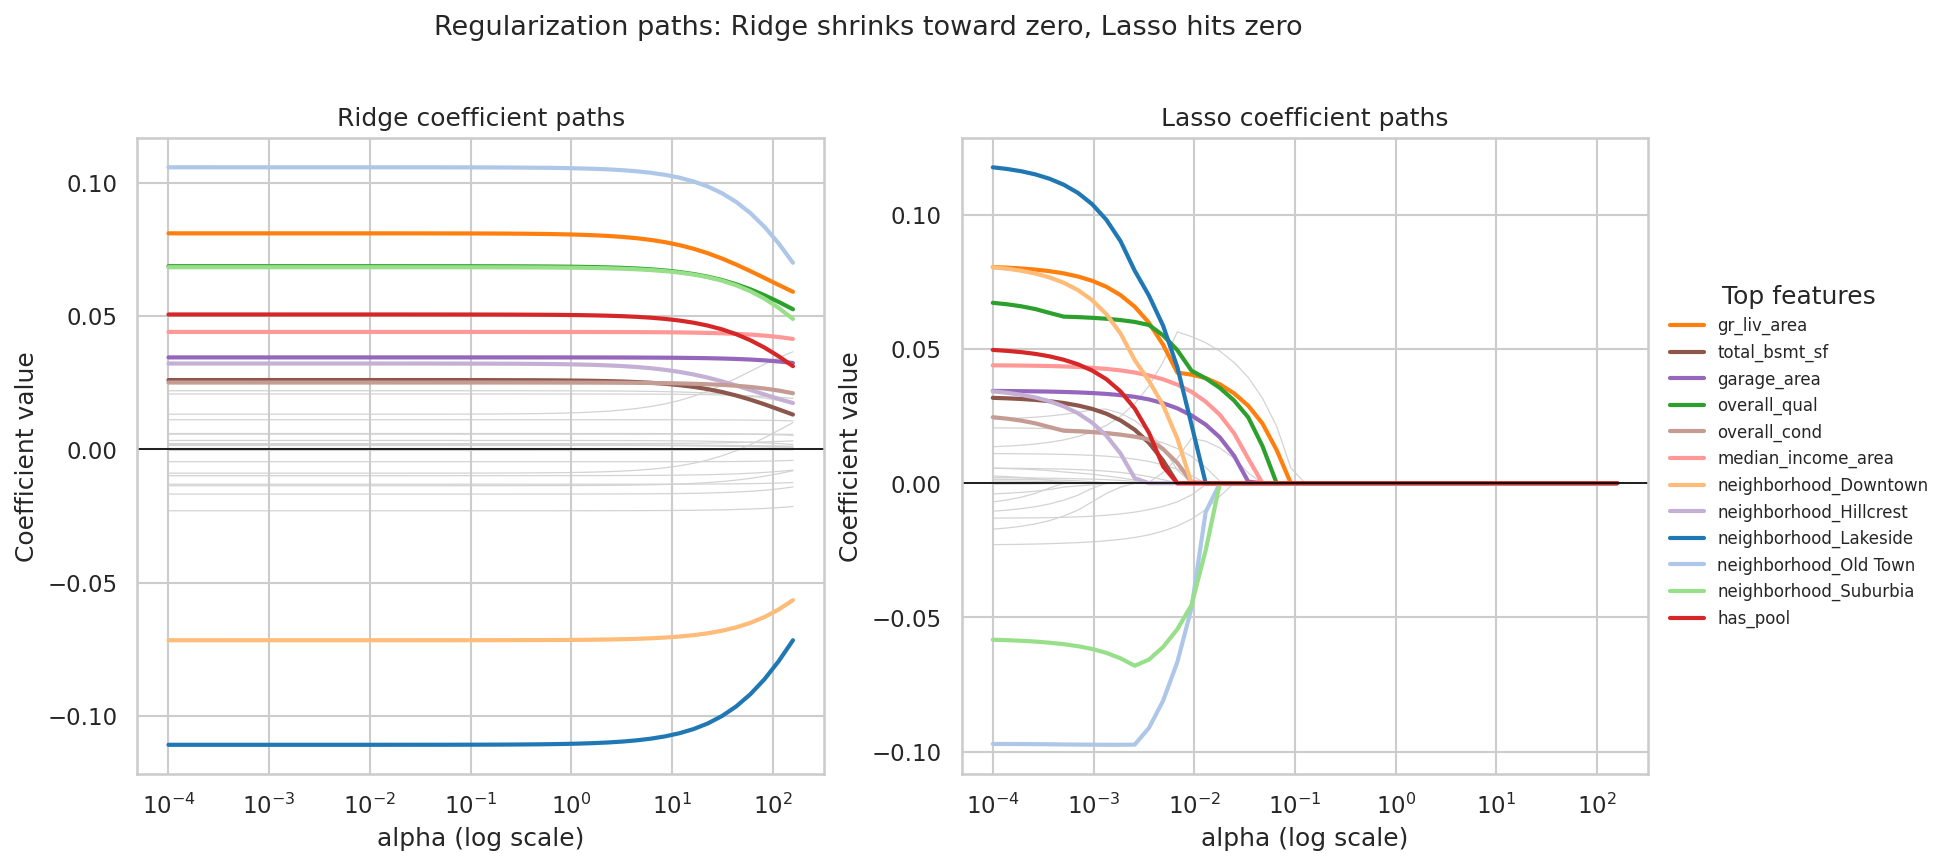

In [14]:
path_alphas = np.logspace(CFG["alpha_search"]["min_exp"], 2.2, 45)
viz.plot_regularization_paths(Xt_train, y_train_log.values, feat_names, path_alphas,
                               Path("/tmp/_paths.png"))
plt.close("all")
Image("/tmp/_paths.png")

## 11. Why does Ridge help? Bootstrap evidence

We bootstrap-resample the training set 200 times at each alpha and refit.
`gr_liv_area`'s coefficient variance falls monotonically as alpha grows —
direct empirical evidence of the bias-variance tradeoff, not just theory.

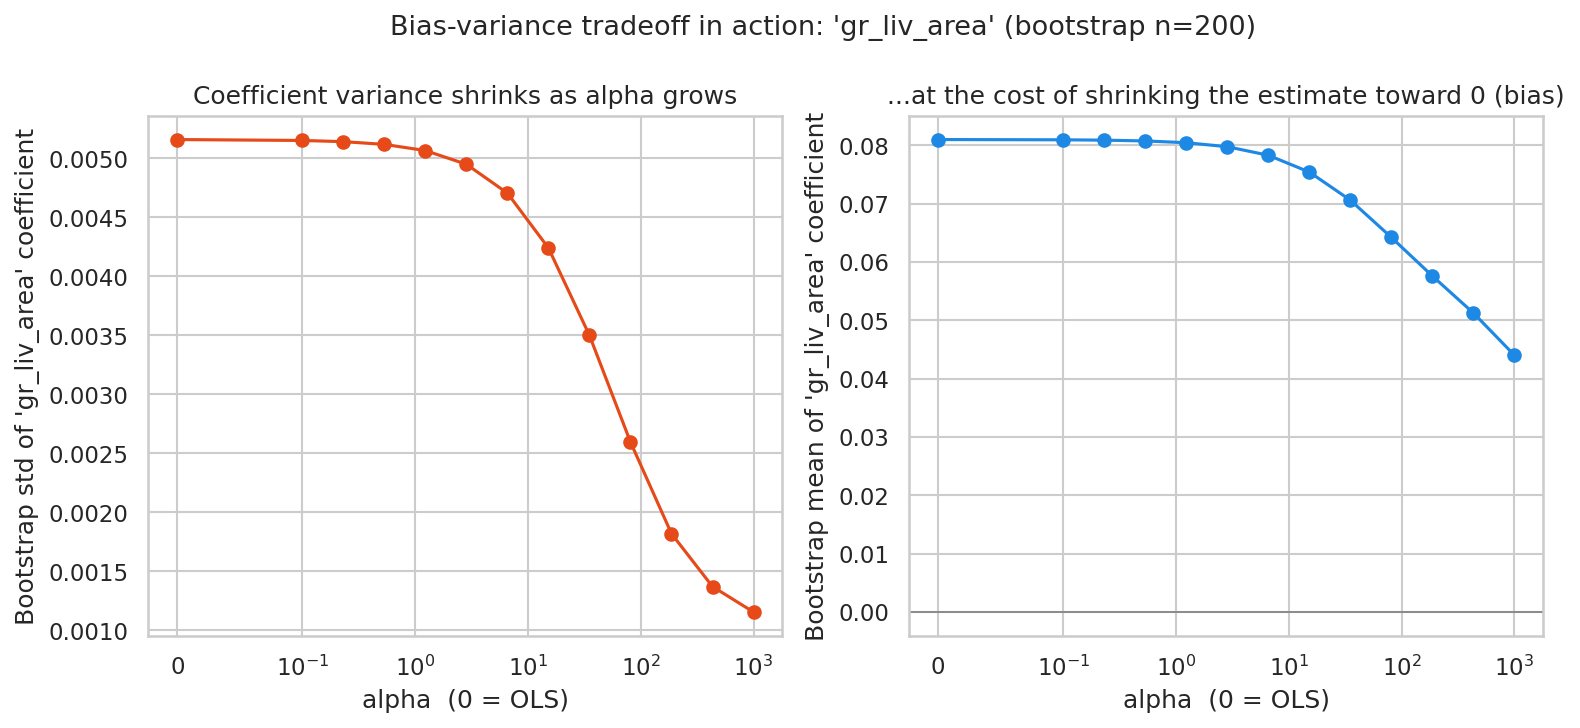

In [15]:
boot_alphas = np.concatenate([[0], np.logspace(-1, 3, 12)])
viz.plot_bootstrap_stability_vs_alpha(
    Xt_train, y_train_log.values, feat_names.index("gr_liv_area"), "gr_liv_area",
    boot_alphas, Path("/tmp/_boot.png"), n_boot=CFG["bootstrap"]["n_iterations"],
)
plt.close("all")
Image("/tmp/_boot.png")

### A subtlety: Ridge's "grouping effect"

Not every correlated feature shrinks toward zero as alpha grows. Watch
`total_sf` (engineered, redundant) versus its two source columns:

In [16]:
grouping = pd.DataFrame(
    {"alpha": a, **{f: Ridge(alpha=a).fit(Xt_train, y_train_log.values).coef_[feat_names.index(f)]
                     for f in ["gr_liv_area", "total_bsmt_sf", "total_sf"]}}
    for a in [0.01, 1, 10, 65, 200, 1000]
)
grouping.round(4)

,alpha,gr_liv_area,total_bsmt_sf,total_sf
0,0.01,0.0810,0.0322,0.0132
1,1.00,0.0805,0.0319,0.0137
2,10.00,0.0771,0.0294,0.0176
3,65.00,0.0662,0.0218,0.0299
4,200.00,0.0573,0.0164,0.0378
5,1000.00,0.0442,0.0120,0.0382


`total_sf`'s coefficient *grows* with alpha while its correlated siblings
shrink — this is Ridge's well-known **grouping effect**: because the L2
penalty on a fixed combined effect is minimized by *spreading* it evenly
across correlated features, Ridge pulls correlated coefficients toward
*each other*, not toward zero. Aggregate stability still improves (the
bootstrap evidence above holds), but "shrinkage" operates on the
correlated group, not coefficient-by-coefficient.

## 12. ElasticNet (bonus)

In [17]:
from sklearn.model_selection import GridSearchCV
en_grid = GridSearchCV(
    make_search_pipeline(ElasticNet(max_iter=20000)),
    {"regressor__alpha": alphas[::4], "regressor__l1_ratio": CFG["elastic_net"]["l1_ratios"]},
    cv=cv, scoring="neg_root_mean_squared_error",
)
en_grid.fit(X_train, y_train_log)
print(en_grid.best_params_)

{'regressor__alpha': np.float64(0.0001), 'regressor__l1_ratio': 0.99}


## 13. Final model comparison on the held-out test set

In [18]:
metrics_df = pd.read_csv(resolve("reports", "model_comparison.csv"))
metrics_df

,model,test_rmse,test_mae,test_r2,test_adj_r2,test_mape_pct,n_nonzero_coefs,n_total_coefs
0,Linear,20034.847565,12308.235617,0.889439,0.882786,3.536213,34,34
1,Ridge (1-SE),20153.154466,12702.856953,0.888129,0.881397,3.668437,34,34
2,Ridge (min),20022.847534,12298.862984,0.889571,0.882926,3.534333,34,34
3,Lasso (1-SE),20608.960969,13062.644119,0.883012,0.875972,3.797113,23,34
4,Lasso (min),19970.329386,12260.392573,0.890150,0.883539,3.526385,32,34
5,ElasticNet,19984.985776,12271.316495,0.889988,0.883368,3.528551,32,34


All models land in a tight band (test R² ≈ 0.88-0.89). **This itself is a
finding, not a disappointment**: with n=2,400 training rows and only 34
features, we're comfortably in the n≫p regime, where OLS is already
fairly stable and regularization's *accuracy* upside is modest. Its real
value here is interpretability (Lasso's feature selection) and coefficient
stability (Ridge's variance reduction) — both demonstrated directly above.
Section 15 shows what happens when n≫p stops being true.

## 14. Residual diagnostics (best model: Ridge, 1-SE alpha)

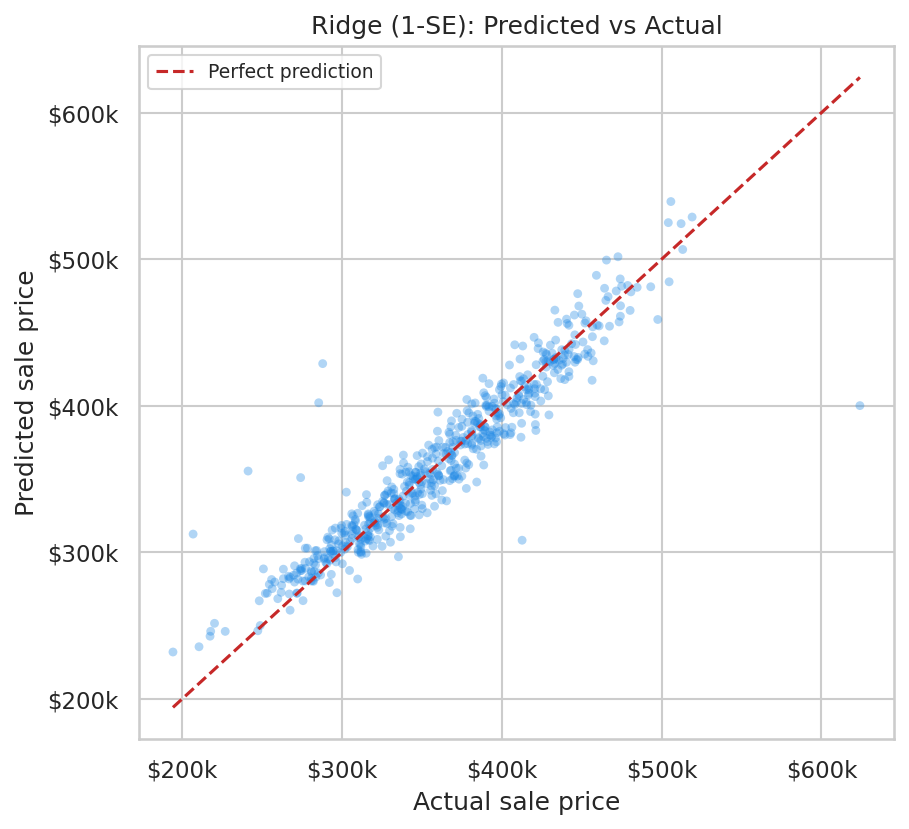

In [19]:
best_pipe = make_production_pipeline(Ridge(alpha=ridge_alpha_1se))
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

viz.plot_predicted_vs_actual(y_test.values, y_pred, Path("/tmp/_pva.png"), "Ridge (1-SE): Predicted vs Actual")
plt.close("all")
Image("/tmp/_pva.png")

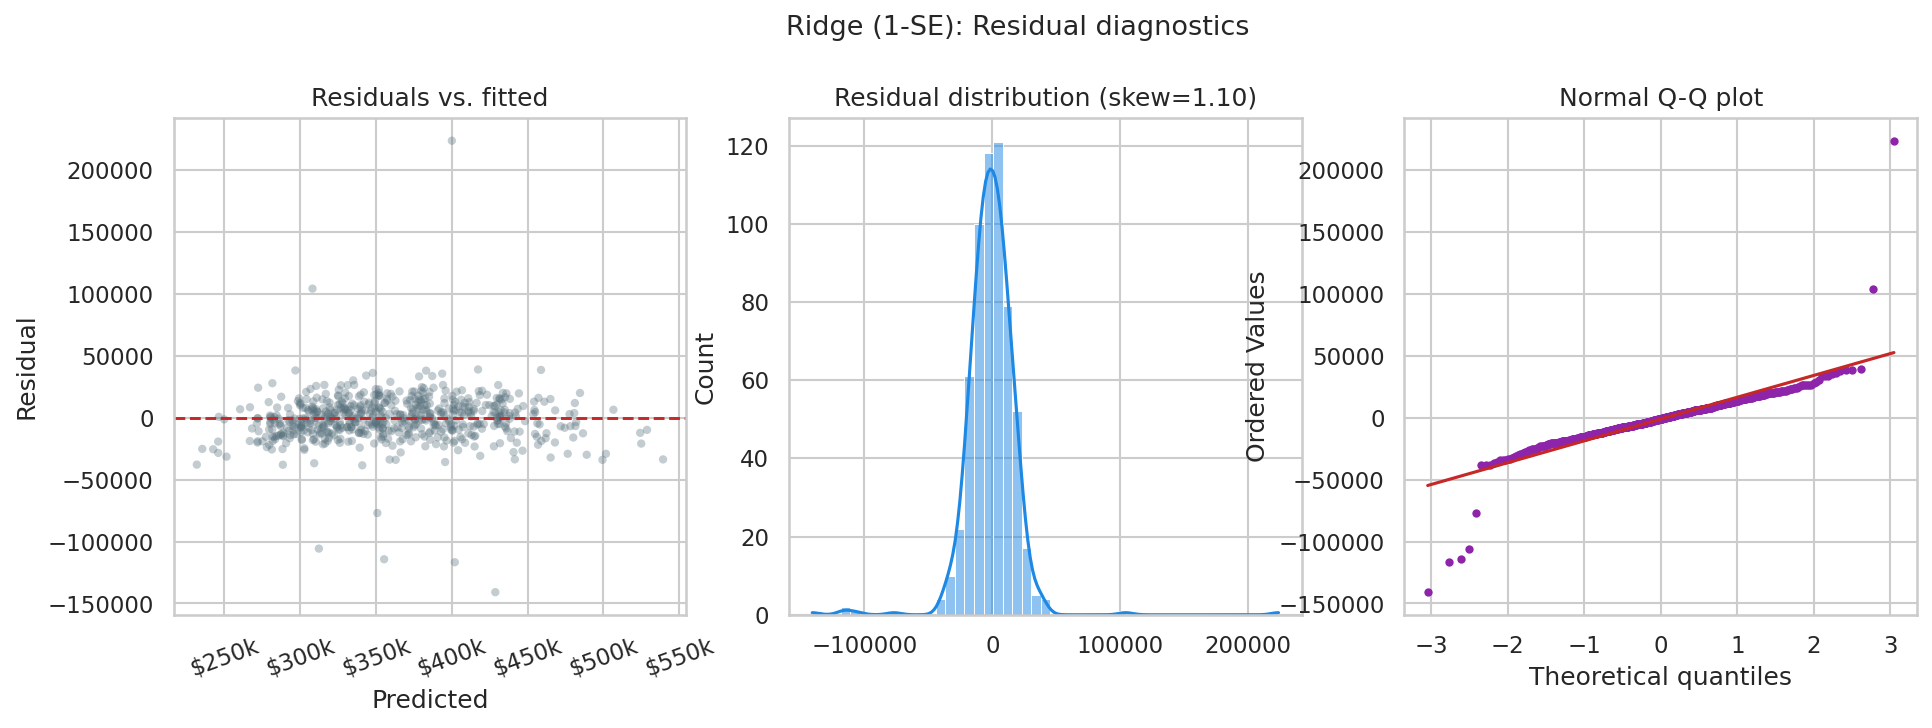

In [20]:
viz.plot_residual_diagnostics(y_test.values, y_pred, Path("/tmp/_resid.png"), "Ridge (1-SE): Residual diagnostics")
plt.close("all")
Image("/tmp/_resid.png")

The Q-Q plot's tail deviation traces back to the outlier/distressed sales
we deliberately injected during data generation — a good candidate for
robust regression (Huber loss) in future work, not a modeling bug.

## 15. Stress test: what if n≫p stops being true?

Everything above lives in a comfortable regime: 2,400 training rows, 34
features (n/p ≈ 70). Let's deliberately make the regime much less
favorable two ways at once: expand to all pairwise interactions among the
numeric features (154 -> way more columns), *and* subsample down to 250
training rows — an n/p ratio of about 1.6, where unregularized OLS is
known to struggle badly.

In [21]:
numeric_for_poly = [c for c in RAW_NUMERIC_FEATURES if "noise" not in c]
X_train_num = X_train_eng[numeric_for_poly].fillna(X_train_eng[numeric_for_poly].median())

N_SUBSAMPLE = 250
X_sub = X_train_num.iloc[:N_SUBSAMPLE]
y_sub = y_train_log.values[:N_SUBSAMPLE]

X_sub_scaled = StandardScaler().fit_transform(X_sub)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X_sub_scaled)
print(f"Expanded {X_sub_scaled.shape[1]} numeric features to {X_poly.shape[1]} (pairwise interactions)")
print(f"Training rows: {X_poly.shape[0]}  ->  n/p = {X_poly.shape[0]/X_poly.shape[1]:.2f}")

Expanded 17 numeric features to 153 (pairwise interactions)
Training rows: 250  ->  n/p = 1.63


In [22]:
from sklearn.model_selection import cross_val_score

poly_scores = {}
for name, model in [("OLS", LinearRegression()), ("Ridge (a=10)", Ridge(alpha=10)),
                     ("Lasso (a=0.01)", Lasso(alpha=0.01, max_iter=50000))]:
    scores = cross_val_score(model, X_poly, y_sub, cv=5, scoring="r2")
    poly_scores[name] = scores
    print(f"{name:16s} CV R²: mean={scores.mean():+.3f}  min={scores.min():+.3f}  (folds: {np.round(scores,3)})")

OLS              CV R²: mean=-1.207  min=-1.777  (folds: [-0.63  -1.731 -1.351 -0.548 -1.777])
Ridge (a=10)     CV R²: mean=+0.138  min=+0.014  (folds: [0.367 0.02  0.047 0.014 0.242])
Lasso (a=0.01)   CV R²: mean=+0.492  min=+0.296  (folds: [0.576 0.419 0.504 0.296 0.663])


With 154 features and only 250 training rows split across 5 CV folds
(~200 rows/fold, n/p ≈ 1.3 within each fold), unregularized OLS's
cross-validated R² goes **strongly negative** — worse than just predicting
the mean every time — while Ridge stays positive and Lasso, whose sparsity
assumption fits this "few real signals among many near-useless interaction
terms" setting particularly well, does best of the three. This is the
regime where regularization stops being a nice-to-have and becomes
load-bearing.

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(poly_scores.values(), tick_labels=poly_scores.keys())
ax.axhline(0, color="#C62828", ls="--", lw=1, label="R²=0 (as good as predicting the mean)")
ax.set_ylabel("CV R² (5 folds)")
ax.set_title(f"High-dimensional stress test: {X_poly.shape[1]} features, {X_poly.shape[0]} rows")
ax.legend()
plt.tight_layout()
plt.savefig(resolve("reports", "figures", "12_stress_test.png"), dpi=150, bbox_inches="tight")
plt.show()

## 16. Conclusions

- **Multicollinearity is real and measurable here** — VIF confirms it
  (one pair is exactly collinear by construction), and statsmodels shows
  its signature: inflated standard errors and meaningless individual
  coefficients for the affected pair, even though overall fit is fine.
- **Ridge stabilizes coefficients** — direct bootstrap evidence, not just
  the textbook claim — though correlated features shrink *toward each
  other* (grouping effect), not always toward zero individually.
- **Lasso does real feature selection** — it correctly zeroed every
  feature we know has zero true effect except one (a good reminder that
  Lasso is a statistical procedure, not an oracle), and the 1-SE vs.
  alpha-min choice is a genuine, explainable trade-off.
- **Regularization's accuracy benefit is regime-dependent.** In our
  n≫p setting it's modest (all models land within ~3% RMSE of each
  other); expand the feature space until n≈p and it becomes essential —
  OLS's CV R² goes negative while Ridge/Lasso stay stable.

## Future work
- Tree-based models (Random Forest, Gradient Boosting) as a non-linear
  benchmark, with SHAP for interpretability.
- Robust regression (Huber/RANSAC) given the outlier sales visible in the
  residual diagnostics.
- Bayesian regression for full posterior uncertainty on predictions, not
  just point estimates.
- Hyperparameter search via Optuna instead of a fixed grid.
- Real data: swap the synthetic generator for an actual MLS feed and
  re-validate every finding above against it.